# P3. Data project: inverse probability weighting on the Lalonde data

Estimate the effect of the job-training program (`treat`) on 1978 earnings (`re78`) with IPTW and a marginal
structural model, using `MatchIt`'s `lalonde` (race as a single factor).

In [1]:
source("setup.R")
use_packages("tableone", "ipw", "survey", "MatchIt")

data("lalonde", package = "MatchIt")
mydata <- data.frame(lalonde)

xvars <- c("age", "educ", "race", "married", "nodegree", "re74", "re75")
print(CreateTableOne(vars = xvars, strata = "treat", data = mydata, test = FALSE), smd = TRUE)

                      Stratified by treat
                       0                 1                 SMD   
  n                        429               185                 
  age (mean (SD))        28.03 (10.79)     25.82 (7.16)     0.242
  educ (mean (SD))       10.24 (2.86)      10.35 (2.01)     0.045
  race (%)                                                  1.701
     black                  87 (20.3)        156 (84.3)          
     hispan                 61 (14.2)         11 ( 5.9)          
     white                 281 (65.5)         18 ( 9.7)          
  married (mean (SD))     0.51 (0.50)       0.19 (0.39)     0.719
  nodegree (mean (SD))    0.60 (0.49)       0.71 (0.46)     0.235
  re74 (mean (SD))     5619.24 (6788.75) 2095.57 (4886.62)  0.596
  re75 (mean (SD))     2466.48 (3292.00) 1532.06 (3219.25)  0.287


## Weights

In [2]:
psmodel <- glm(treat ~ age + educ + race + married + nodegree + re74 + re75,
               family = binomial(link = "logit"), data = mydata)
ps <- predict(psmodel, type = "response")

# 1/PS for the treated, 1/(1-PS) for controls
weight <- ifelse(mydata$treat == 1, 1 / ps, 1 / (1 - ps))
summary(weight)

# weighted Table 1
weighteddata <- svydesign(ids = ~1, data = mydata, weights = ~weight)
print(svyCreateTableOne(vars = xvars, strata = "treat", data = weighteddata, test = FALSE), smd = TRUE)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  1.009   1.052   1.170   1.905   1.623  40.077 

                      Stratified by treat
                       0                 1                 SMD   
  n                     616.00            553.63                 
  age (mean (SD))        27.10 (10.80)     25.57 (6.53)     0.172
  educ (mean (SD))       10.29 (2.74)      10.61 (2.05)     0.132
  race (%)                                                  0.112
     black               245.1 (39.8)      247.9 (44.8)          
     hispan               72.1 (11.7)       67.4 (12.2)          
     white               298.8 (48.5)      238.3 (43.0)          
  married (mean (SD))     0.41 (0.49)       0.31 (0.47)     0.197
  nodegree (mean (SD))    0.62 (0.48)       0.57 (0.50)     0.112
  re74 (mean (SD))     4552.74 (6337.09) 2932.18 (5709.42)  0.269
  re75 (mean (SD))     2172.04 (3160.14) 1658.07 (3072.89)  0.165


## Marginal structural model with the `ipw` package

The difference in mean 1978 earnings, treated minus untreated, in the weighted population; then the same with
weights truncated at their 1st and 99th percentiles.

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  1.009   1.052   1.170   1.905   1.623  40.077 

(Intercept)       treat 
  6422.8390    224.6763

,2.5 %,97.5 %
(Intercept),5705.529,7140.149
treat,-1562.856,2012.208


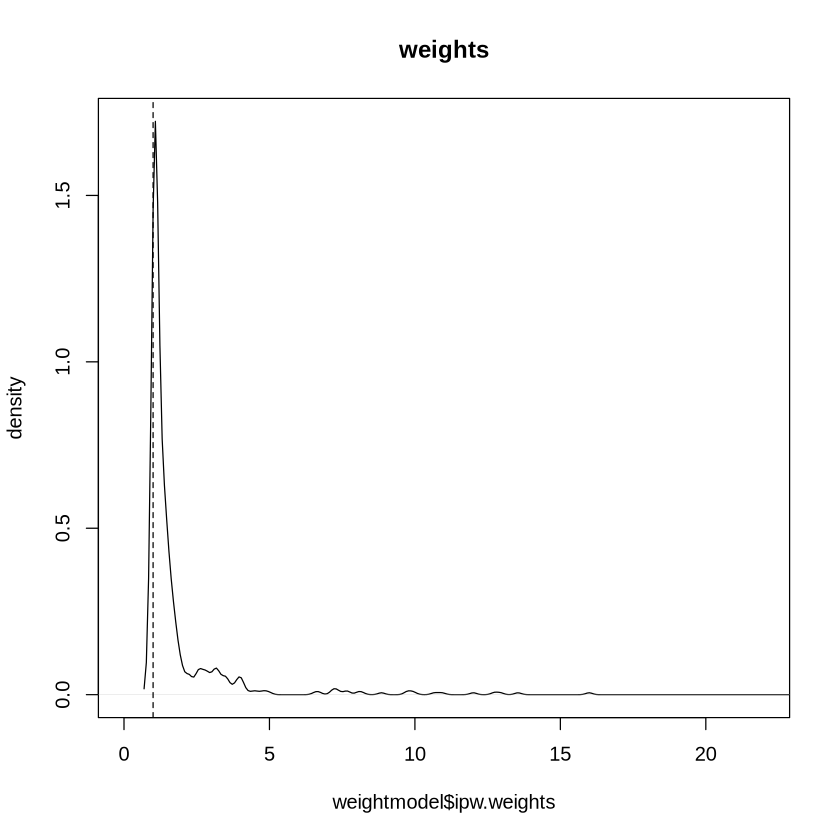

In [3]:
weightmodel <- ipwpoint(exposure = treat, family = "binomial", link = "logit",
                        denominator = ~ age + educ + race + married + nodegree + re74 + re75, data = mydata)
summary(weightmodel$ipw.weights)
ipwplot(weights = weightmodel$ipw.weights, logscale = FALSE, main = "weights", xlim = c(0, 22))

mydata$wt <- weightmodel$ipw.weights
msm <- svyglm(re78 ~ treat, design = svydesign(~1, weights = ~wt, data = mydata))
coef(msm)
confint(msm)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  1.012   1.052   1.170   1.818   1.623  12.631 

(Intercept)       treat 
  6422.9362    486.9336

,2.5 %,97.5 %
(Intercept),5705.614,7140.258
treat,-1093.765,2067.632


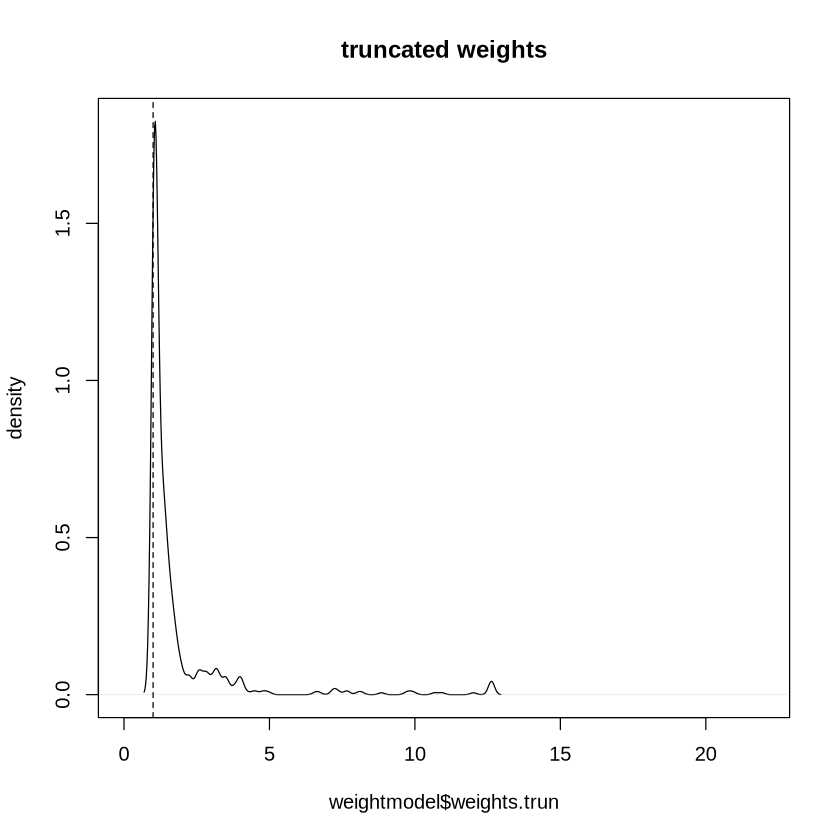

In [4]:
weightmodel <- ipwpoint(exposure = treat, family = "binomial", link = "logit",
                        denominator = ~ age + educ + race + married + nodegree + re74 + re75,
                        data = mydata, trunc = .01)
summary(weightmodel$weights.trun)
ipwplot(weights = weightmodel$weights.trun, logscale = FALSE, main = "truncated weights", xlim = c(0, 22))

mydata$wt <- weightmodel$weights.trun
msm <- svyglm(re78 ~ treat, design = svydesign(~1, weights = ~wt, data = mydata))
coef(msm)
confint(msm)